In [29]:
# ============================================================
# CLUSTERING COMPARISON: DBSCAN vs OPTICS
# Datasets: make_blobs (different densities) & noisy make_moons
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import DBSCAN, OPTICS
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
    calinski_harabasz_score
)

# ============================================================
# Helper function: plot clusters with counts
# ============================================================
def plot_clusters(X, labels, title, ax, true_k=None):
    """Visualize clusters in 2D using PCA and show cluster count."""
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    unique_labels = set(labels)
    n_clusters = len(unique_labels - {-1})  # exclude noise (-1)
    noise_points = list(labels).count(-1)

    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', s=25)
    label_info = f"Clusters={n_clusters}"
    if noise_points > 0:
        label_info += f", Noise={noise_points}"
    if true_k is not None:
        label_info += f", True={true_k}"
    ax.set_title(f"{title}\n({label_info})", fontsize=10)
    ax.grid(True)


In [30]:
# ============================================================
# Helper function: evaluate clustering metrics
# ============================================================
def evaluate_clustering(X, y_true, y_pred):
    mask = y_pred != -1  # exclude noise points for valid metrics
    if len(np.unique(y_pred[mask])) > 1:
        silhouette = silhouette_score(X[mask], y_pred[mask])
        calinski = calinski_harabasz_score(X[mask], y_pred[mask])
    else:
        silhouette, calinski = np.nan, np.nan

    return {
        "ARI": adjusted_rand_score(y_true, y_pred),
        "NMI": normalized_mutual_info_score(y_true, y_pred),
        "Silhouette": silhouette,
        "Calinski": calinski,
    }


In [37]:
# ============================================================
# Dataset 1: make_blobs with variable densities
# ============================================================
X_blobs, y_blobs = make_blobs(
    n_samples=[300, 300, 300, 300],
    centers=[[0, 0], [8, 0], [0, 8], [8, 8]],
    cluster_std=[0.5, 1.2, 2.5, 0.8],
    random_state=80
)
X_blobs = StandardScaler().fit_transform(X_blobs)

# ============================================================
# Dataset 2: noisy moons
# ============================================================
X_moons, y_moons = make_moons(n_samples=600, noise=0.2, random_state=42)
X_moons = StandardScaler().fit_transform(X_moons)

# ============================================================
# Define clustering methods
# ============================================================
datasets = {
    "variable_blobs": (X_blobs, y_blobs),
    "noisy_moons": (X_moons, y_moons)
}


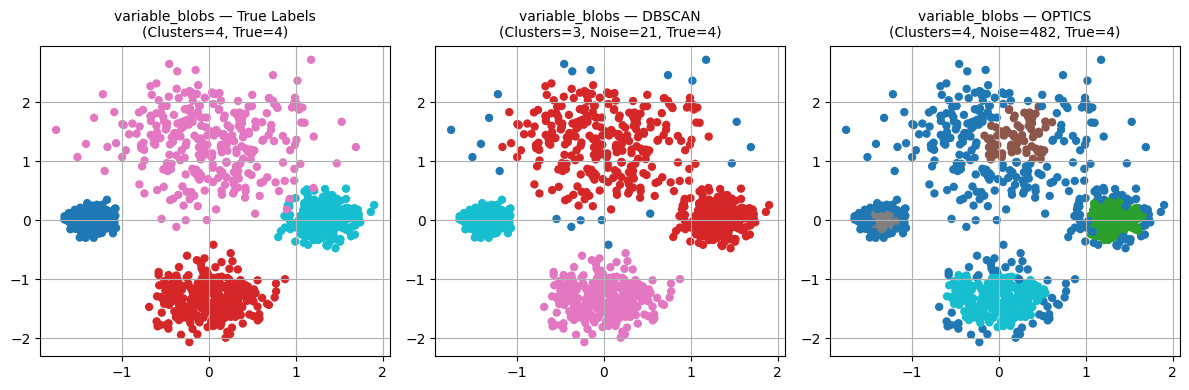

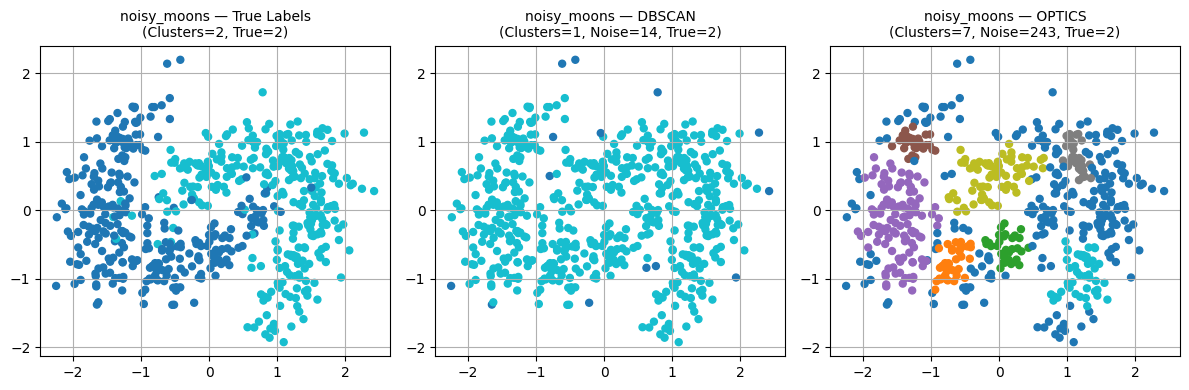

In [38]:
summary = []

# ============================================================
# Run DBSCAN & OPTICS on each dataset
# ============================================================
for name, (X, y_true) in datasets.items():
    true_k = len(np.unique(y_true))

    # DBSCAN
    db = DBSCAN(eps=0.25, min_samples=5).fit(X)
    y_db = db.labels_

    # OPTICS
    optics = OPTICS(min_samples=5, xi=0.05, min_cluster_size=0.05).fit(X)
    y_opt = optics.labels_

    # Evaluate
    db_metrics = evaluate_clustering(X, y_true, y_db)
    opt_metrics = evaluate_clustering(X, y_true, y_opt)

    # Count clusters and noise
    n_true = len(np.unique(y_true))
    n_db = len(set(y_db) - {-1})
    n_opt = len(set(y_opt) - {-1})
    noise_db = list(y_db).count(-1)
    noise_opt = list(y_opt).count(-1)

    summary.append({
        "Dataset": name,
        "True_Clusters": n_true,
        "DBSCAN_Clusters": n_db,
        "DBSCAN_Noise": noise_db,
        **{f"DBSCAN_{k}": v for k, v in db_metrics.items()},
        "OPTICS_Clusters": n_opt,
        "OPTICS_Noise": noise_opt,
        **{f"OPTICS_{k}": v for k, v in opt_metrics.items()},
    })

    # ============================================================
    # Plot comparisons
    # ============================================================
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    plot_clusters(X, y_true, f"{name} — True Labels", axes[0], true_k=true_k)
    plot_clusters(X, y_db, f"{name} — DBSCAN", axes[1], true_k=true_k)
    plot_clusters(X, y_opt, f"{name} — OPTICS", axes[2], true_k=true_k)
    plt.tight_layout()
    plt.show()


In [39]:
# ============================================================
# Display Summary Table
# ============================================================

pd.set_option('mode.use_inf_as_na', True)
summary_df = pd.DataFrame(summary)
summary_df.fillna(0).round(3)

print("\n=== CLUSTERING SUMMARY ===")
display(summary_df.round(3))



=== CLUSTERING SUMMARY ===


/tmp/ipykernel_48/388890074.py:5: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.set_option('mode.use_inf_as_na', True)
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Dataset,True_Clusters,DBSCAN_Clusters,DBSCAN_Noise,DBSCAN_ARI,DBSCAN_NMI,DBSCAN_Silhouette,DBSCAN_Calinski,OPTICS_Clusters,OPTICS_Noise,OPTICS_ARI,OPTICS_NMI,OPTICS_Silhouette,OPTICS_Calinski
0,variable_blobs,4,3,21,0.709,0.838,0.571,1296.572,4,482,0.472,0.627,0.828,6204.159
1,noisy_moons,2,1,14,-0.000,0.001,NaN,NaN,7,243,0.131,0.295,0.469,518.243


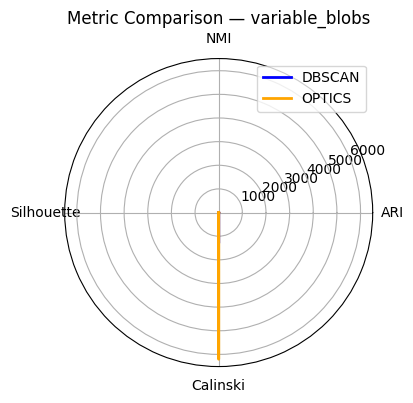

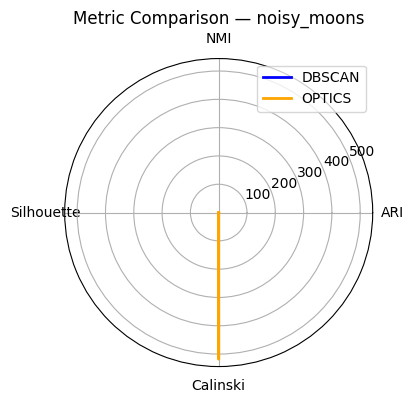

In [41]:

# ============================================================
# Radar Chart Comparison
# ============================================================
def plot_radar_chart(df, dataset_name):
    """Plot radar chart comparing DBSCAN vs OPTICS."""
    metrics = ["ARI", "NMI", "Silhouette", "Calinski"]
    subset = df[df["Dataset"] == dataset_name]
    if subset.empty:
        return

    db_vals = subset[[f"DBSCAN_{m}" for m in metrics]].values.flatten()
    opt_vals = subset[[f"OPTICS_{m}" for m in metrics]].values.flatten()
    db_vals = np.nan_to_num(db_vals, nan=0)
    opt_vals = np.nan_to_num(opt_vals, nan=0)

    labels = metrics
    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
    db_vals = np.concatenate((db_vals, [db_vals[0]]))
    opt_vals = np.concatenate((opt_vals, [opt_vals[0]]))
    angles += [angles[0]]

    fig, ax = plt.subplots(figsize=(4, 4), subplot_kw=dict(polar=True))
    ax.plot(angles, db_vals, label="DBSCAN", color="blue", linewidth=2)
    ax.fill(angles, db_vals, alpha=0.2, color="blue")
    ax.plot(angles, opt_vals, label="OPTICS", color="orange", linewidth=2)
    ax.fill(angles, opt_vals, alpha=0.2, color="orange")
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_title(f"Metric Comparison — {dataset_name}")
    ax.legend(loc="upper right")
    plt.show()

for dataset_name in datasets.keys():
    plot_radar_chart(summary_df, dataset_name)


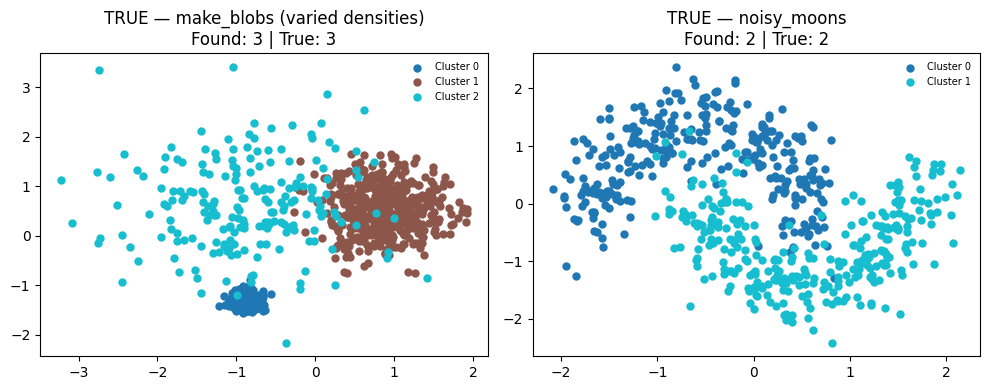

In [43]:
# ============================================
# DBSCAN vs OPTICS — Final Tuned Comparison
# With Metrics + Radar Chart
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import DBSCAN, OPTICS
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)
import pandas as pd

# -------------------------------
# 1. Generate datasets
# -------------------------------
X1, y1 = make_blobs(
    n_samples=[300, 500, 200],
    centers=[[0, 0], [5, 5], [0, 5]],
    cluster_std=[0.3, 1.2, 2.5],
    random_state=42
)
X2, y2 = make_moons(n_samples=600, noise=0.2, random_state=42)

X1 = StandardScaler().fit_transform(X1)
X2 = StandardScaler().fit_transform(X2)

# -------------------------------
# 2. Define helper functions
# -------------------------------
def evaluate_clustering(X, y_true, y_pred):
    """Compute key clustering metrics."""
    mask = y_pred != -1  # ignore noise for silhouette
    if len(set(y_pred)) <= 1 or np.sum(mask) < 2:
        return dict(ARI=np.nan, NMI=np.nan, Silhouette=np.nan, CHI=np.nan, DBI=np.nan)

    return dict(
        ARI=adjusted_rand_score(y_true, y_pred),
        NMI=normalized_mutual_info_score(y_true, y_pred),
        Silhouette=silhouette_score(X[mask], y_pred[mask]),
        CHI=calinski_harabasz_score(X[mask], y_pred[mask]),
        DBI=davies_bouldin_score(X[mask], y_pred[mask]),
    )

def plot_clusters(X, labels, title, ax, true_clusters=None):
    """Plot clusters."""
    unique_labels = np.unique(labels)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
    for label, color in zip(unique_labels, colors):
        mask = (labels == label)
        ax.scatter(X[mask, 0], X[mask, 1], s=25, color=color, label=f"Cluster {label}")
    ax.set_title(f"{title}\nFound: {len(unique_labels)} | True: {true_clusters}")
    ax.legend(loc="upper right", fontsize=7, frameon=False)

# -------------------------------
# 3. True Data Visuals
# -------------------------------
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
plot_clusters(X1, y1, "TRUE — make_blobs (varied densities)", ax[0], len(np.unique(y1)))
plot_clusters(X2, y2, "TRUE — noisy_moons", ax[1], len(np.unique(y2)))
plt.tight_layout()
plt.show()

# -------------------------------
# 4. Apply DBSCAN + OPTICS
# -------------------------------
dbscan_blobs = DBSCAN(eps=0.35, min_samples=8).fit(X1)
dbscan_moons = DBSCAN(eps=0.25, min_samples=10).fit(X2)

optics_blobs = OPTICS(min_samples=8, xi=0.05, min_cluster_size=0.03,
                      cluster_method='xi', metric='minkowski').fit(X1)
optics_moons = OPTICS(min_samples=5, xi=0.02, min_cluster_size=0.03,
                      cluster_method='xi', metric='minkowski').fit(X2)

y_db_blobs, y_db_moons = dbscan_blobs.labels_, dbscan_moons.labels_
y_op_blobs, y_op_moons = optics_blobs.labels_, optics_moons.labels_




=== METRICS SUMMARY ===
       Dataset Algorithm    ARI    NMI  Silhouette       CHI    DBI
0   make_blobs    DBSCAN  0.655  0.705       0.632  1732.952  0.414
1   make_blobs    OPTICS  0.659  0.620       0.789  4221.671  0.233
2  noisy_moons    DBSCAN  0.603  0.503       0.439   583.628  0.885
3  noisy_moons    OPTICS  0.029  0.214       0.698  1087.000  0.406


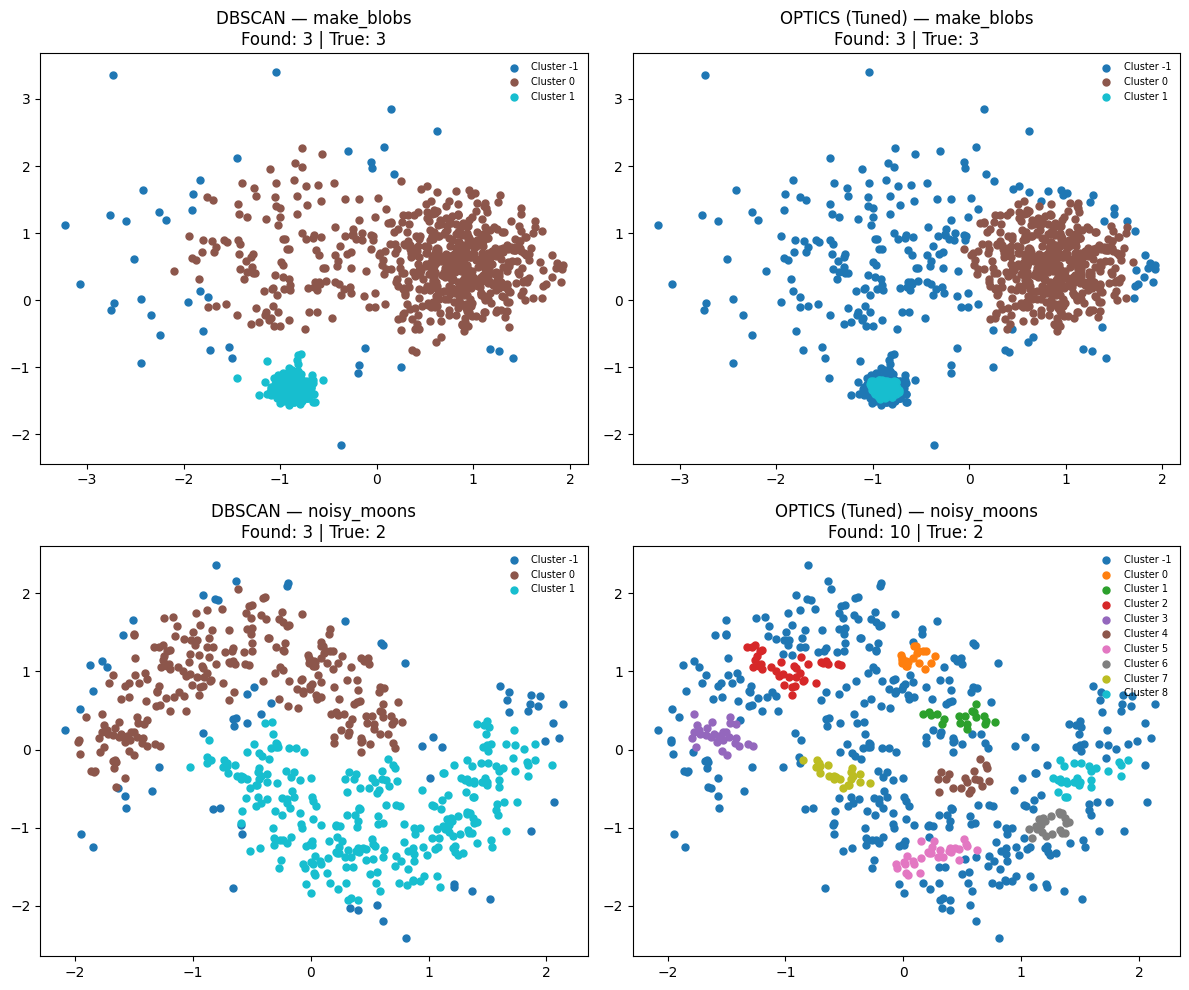

In [44]:
# -------------------------------
# 5. Metrics Summary
# -------------------------------
results = pd.DataFrame([
    {"Dataset": "make_blobs", "Algorithm": "DBSCAN", **evaluate_clustering(X1, y1, y_db_blobs)},
    {"Dataset": "make_blobs", "Algorithm": "OPTICS", **evaluate_clustering(X1, y1, y_op_blobs)},
    {"Dataset": "noisy_moons", "Algorithm": "DBSCAN", **evaluate_clustering(X2, y2, y_db_moons)},
    {"Dataset": "noisy_moons", "Algorithm": "OPTICS", **evaluate_clustering(X2, y2, y_op_moons)},
])

print("\n=== METRICS SUMMARY ===")
print(results.round(3))


# -------------------------------
# 6. Visualization — Cluster Plots
# -------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

plot_clusters(X1, y_db_blobs, "DBSCAN — make_blobs", axes[0, 0], len(np.unique(y1)))
plot_clusters(X1, y_op_blobs, "OPTICS (Tuned) — make_blobs", axes[0, 1], len(np.unique(y1)))

plot_clusters(X2, y_db_moons, "DBSCAN — noisy_moons", axes[1, 0], len(np.unique(y2)))
plot_clusters(X2, y_op_moons, "OPTICS (Tuned) — noisy_moons", axes[1, 1], len(np.unique(y2)))

plt.tight_layout()
plt.show()


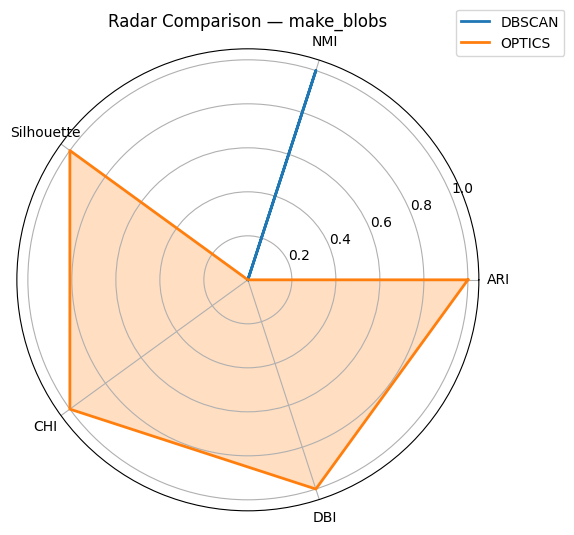

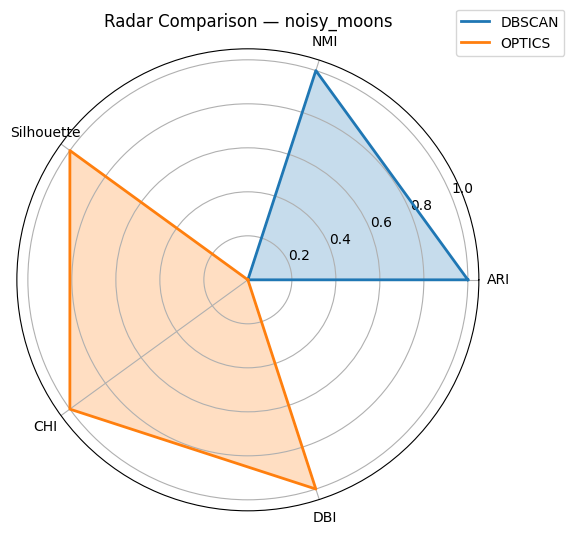

In [45]:

# -------------------------------
# 7. Radar Chart — Metric Comparison
# -------------------------------
def plot_radar(df, dataset):
    """Radar plot comparing metrics."""
    metrics = ["ARI", "NMI", "Silhouette", "CHI", "DBI"]
    subset = df[df["Dataset"] == dataset]
    labels = subset["Algorithm"].values
    values = subset[metrics].values

    # Normalize each metric (DBI inverted)
    norm_values = np.zeros_like(values)
    for i, metric in enumerate(metrics):
        col = subset[metric].values.copy()
        if metric == "DBI":  # lower is better
            col = np.max(col) - col + np.min(col)
        norm_values[:, i] = (col - np.min(col)) / (np.max(col) - np.min(col) + 1e-9)

    angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
    norm_values = np.concatenate((norm_values, norm_values[:, [0]]), axis=1)
    angles += angles[:1]

    fig, ax = plt.subplots(subplot_kw=dict(polar=True), figsize=(6, 6))
    for i in range(len(labels)):
        ax.plot(angles, norm_values[i], label=labels[i], linewidth=2)
        ax.fill(angles, norm_values[i], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics)
    ax.set_title(f"Radar Comparison — {dataset}")
    ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))
    plt.show()

plot_radar(results, "make_blobs")
plot_radar(results, "noisy_moons")
